# DRL Weight Comparison: GLI / GCI

In [1]:
import numpy as np

from drl_weight_plot_utils import (
    build_model_specs,
    load_raindata,
    load_record,
    pick_events_by_peak_gradient,
    plot_delta_regression_figure,
    plot_gli_process_figure,
    set_plot_style,
    validate_required_records,
)

set_plot_style()

In [ ]:
# Core configuration
RESULTS_DIR = 'results_weights'
REAL_RESULTS_DIR = 'results_m_real_weights'
DELTA_REG_FIGURE_PATH = 'figures_drl_weight_compare/gli_delta_regression_drl_weights.png'
GLI_PROCESS_FIGURE_PATH = 'figures_drl_weight_compare/gli_process_drl_weights.png'

START_IDX = 50
NUM_RAINFALLS = 30
ONE_STEP_MINUTES = 5
N_PICK = 4
REAL_EVENTS = [0, 1, 2, 3]

# Reference files used in Δ1 / GCI calculation
BASELINE_RECORD_PATH = 'results/HC.npy'
BASELINE_PATH = ['env4']
GI_ONLY_RECORD_PATH = 'results/HC_GI.npy'
GI_ONLY_PATH = ['env3']

BASELINE_REAL_RECORD_PATH = 'results_m_real/HC.npy'
BASELINE_REAL_PATH = ['env4']
GI_ONLY_REAL_RECORD_PATH = 'results_m_real/HC_GI.npy'
GI_ONLY_REAL_PATH = ['env3']

DRL_MODELS = [
    {'label': '(0.9,0.1)', 'file': 'DQN3_GI_new_91.npy'},
    {'label': '(0.8,0.2)', 'file': 'DQN3_GI_new_82.npy'},
    {'label': '(0.7,0.3)', 'file': 'DQN3_GI_new_73.npy'},
    {'label': '(0.6,0.4)', 'file': 'DQN3_GI_new_64.npy'},
    {'label': '(0.5,0.5)', 'file': 'DQN3_GI_new_55.npy'},
]

DRL_MODELS


[{'label': '(0.9,0.1)', 'file': 'DQN3_GI_new_91.npy'},
 {'label': '(0.8,0.2)', 'file': 'DQN3_GI_new_82.npy'},
 {'label': '(0.7,0.3)', 'file': 'DQN3_GI_new_73.npy'},
 {'label': '(0.6,0.4)', 'file': 'DQN3_GI_new_64.npy'},
 {'label': '(0.5,0.5)', 'file': 'DQN3_GI_new_55.npy'}]

In [3]:
required_paths = {
    'baseline': BASELINE_RECORD_PATH,
    'gi_only': GI_ONLY_RECORD_PATH,
    'baseline_real': BASELINE_REAL_RECORD_PATH,
    'gi_only_real': GI_ONLY_REAL_RECORD_PATH,
}
for spec in DRL_MODELS:
    required_paths[f"drl::{spec['label']}"] = spec.get('path', f"{RESULTS_DIR}/{spec['file']}")
    required_paths[f"drl_real::{spec['label']}"] = spec.get('real_path', f"{REAL_RESULTS_DIR}/{spec['file']}")

resolved_paths = validate_required_records(required_paths)
raindata = load_raindata()
rain_ids = list(range(START_IDX, START_IDX + NUM_RAINFALLS))
baseline_record = load_record(BASELINE_RECORD_PATH)
gi_only_record = load_record(GI_ONLY_RECORD_PATH)
baseline_real_record = load_record(BASELINE_REAL_RECORD_PATH)
gi_only_real_record = load_record(GI_ONLY_REAL_RECORD_PATH)
model_specs = build_model_specs(DRL_MODELS, results_dir=RESULTS_DIR)
real_model_specs = build_model_specs(DRL_MODELS, results_dir=REAL_RESULTS_DIR)
chosen_events, chosen_peaks = pick_events_by_peak_gradient(raindata, START_IDX, NUM_RAINFALLS, N_PICK)

print('Loaded design-rain models:', [spec['label'] for spec in model_specs])
print('Loaded real-rain models:', [spec['label'] for spec in real_model_specs])
print('Resolved baseline path:', resolved_paths['baseline'])
print('Resolved GI-only path:', resolved_paths['gi_only'])
print('Resolved real baseline path:', resolved_paths['baseline_real'])
print('Resolved real GI-only path:', resolved_paths['gi_only_real'])
print('Selected design events:', chosen_events)
print('Selected peaks:', chosen_peaks)
print('Real events:', REAL_EVENTS)


Loaded design-rain models: ['(0.9,0.1)', '(0.8,0.2)', '(0.7,0.3)', '(0.6,0.4)', '(0.5,0.5)']
Loaded real-rain models: ['(0.9,0.1)', '(0.8,0.2)', '(0.7,0.3)', '(0.6,0.4)', '(0.5,0.5)']
Resolved baseline path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\HC.npy
Resolved GI-only path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results\HC_GI.npy
Resolved real baseline path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_m_real\HC.npy
Resolved real GI-only path: D:\from_E\School\School\FYP\Green_infrastructure_RTC\New_reward\v9_new_reward_nonnegative\DRL-GI\results_m_real\HC_GI.npy
Selected design events: [70, 64, 67, 51]
Selected peaks: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]
Real events: [0, 1, 2, 3]


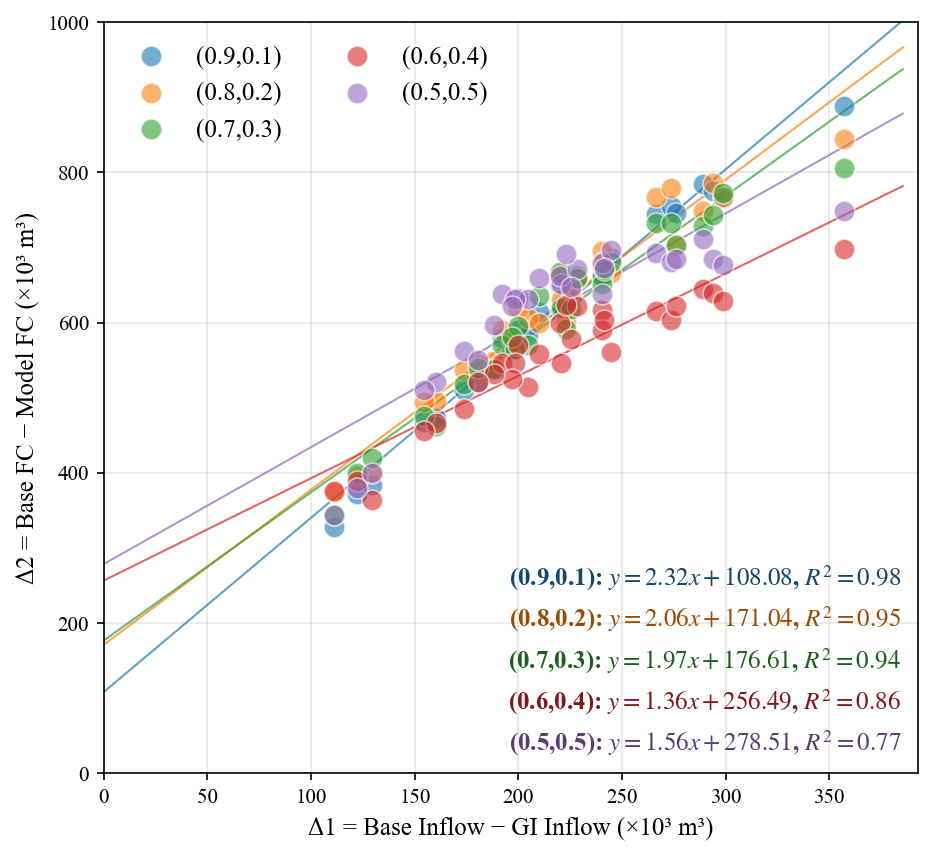

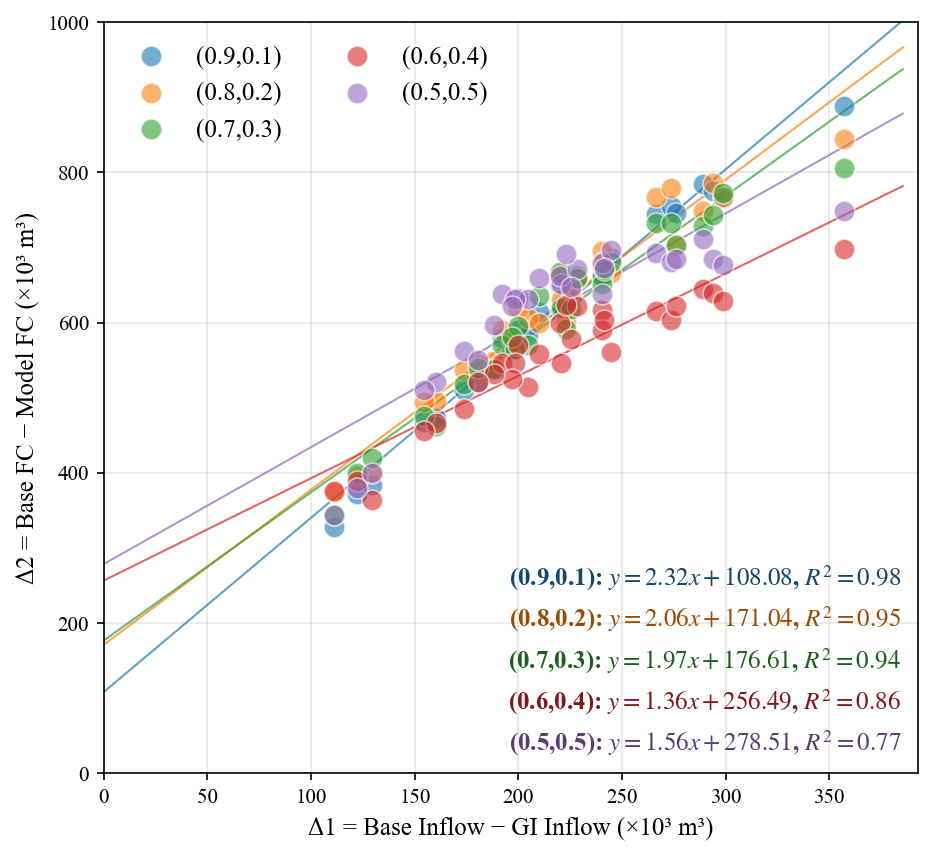

In [4]:
fig_reg, delta_1, delta_2_map = plot_delta_regression_figure(
    model_specs=model_specs,
    base_record=baseline_record,
    base_path=BASELINE_PATH,
    gi_record=gi_only_record,
    gi_path=GI_ONLY_PATH,
    rain_ids=rain_ids,
    save_path=DELTA_REG_FIGURE_PATH,
)
fig_reg

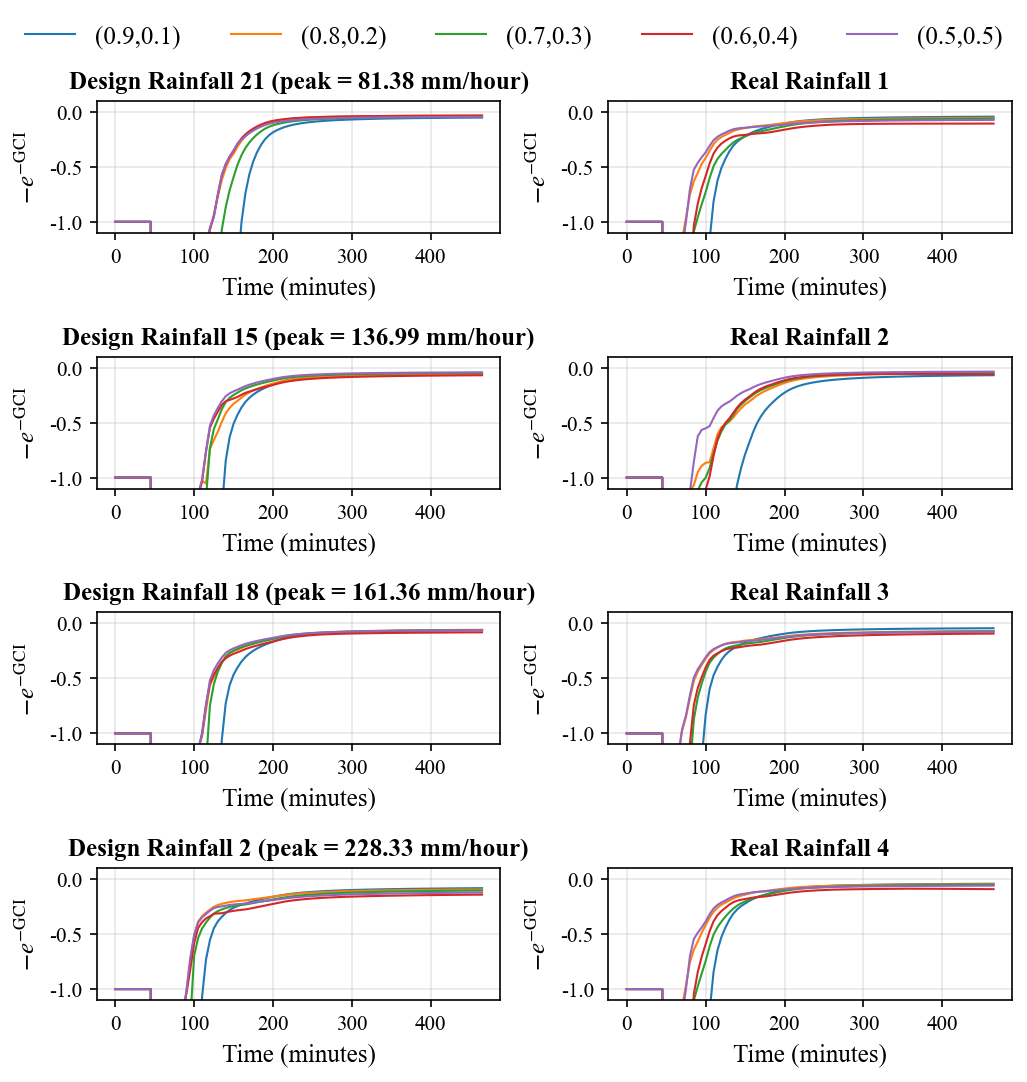

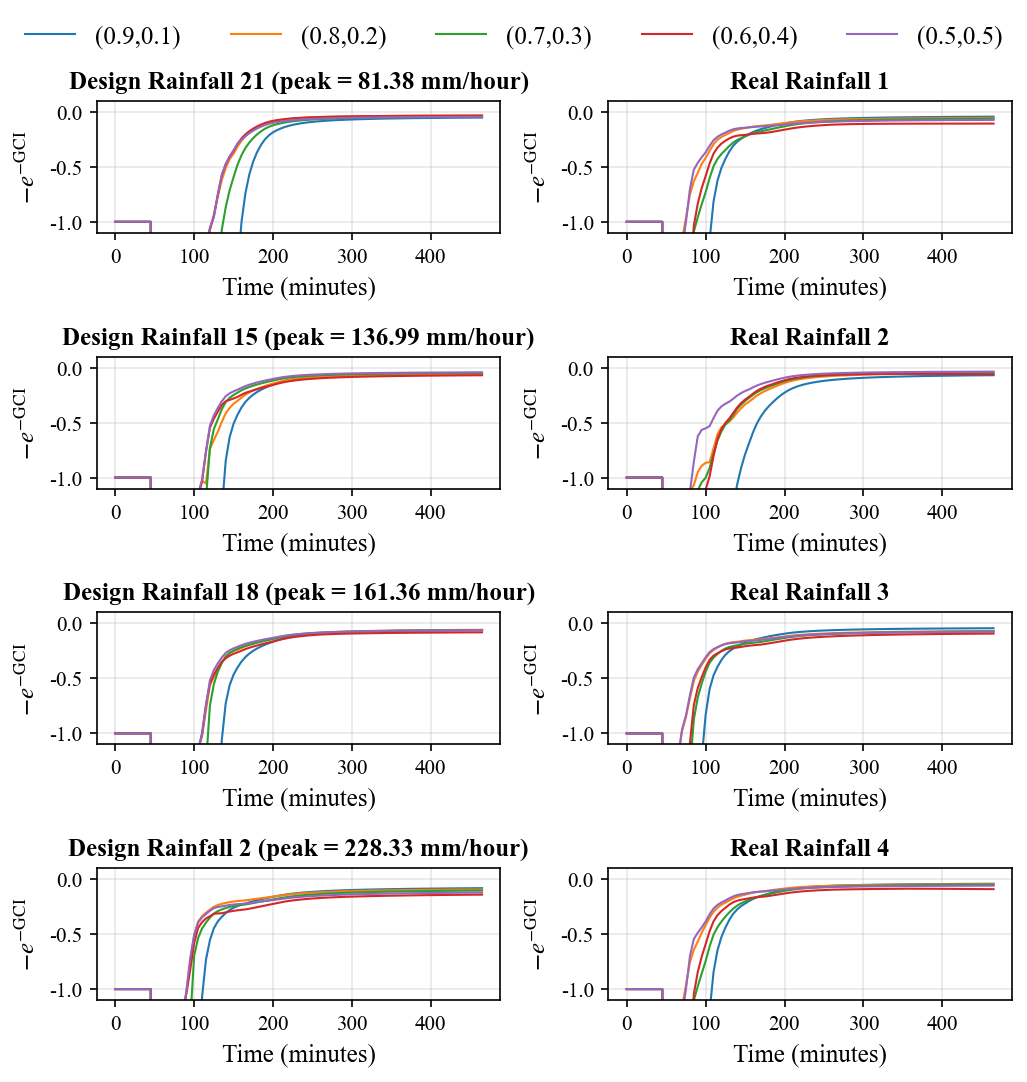

In [5]:
fig_gli = plot_gli_process_figure(
    model_specs=model_specs,
    base_record=baseline_record,
    base_path=BASELINE_PATH,
    gi_record=gi_only_record,
    gi_path=GI_ONLY_PATH,
    chosen_events=chosen_events,
    chosen_peaks=chosen_peaks,
    rain_start=START_IDX,
    one_step_minutes=ONE_STEP_MINUTES,
    real_model_specs=real_model_specs,
    real_base_record=baseline_real_record,
    real_base_path=BASELINE_REAL_PATH,
    real_gi_record=gi_only_real_record,
    real_gi_path=GI_ONLY_REAL_PATH,
    real_events=REAL_EVENTS,
    save_path=GLI_PROCESS_FIGURE_PATH,
)
fig_gli


In [6]:
# Optional quick summary
summary = {
    label: {
        'mean_delta2': float(values.mean()),
        'median_delta2': float(np.median(values)),
        'max_delta2': float(values.max()),
        'min_delta2': float(values.min()),
    }
    for label, values in delta_2_map.items()
}
summary

{'(0.9,0.1)': {'mean_delta2': 615.5397860337127,
  'median_delta2': 627.8266837757615,
  'max_delta2': 888.7073956418277,
  'min_delta2': 327.598189145621},
 '(0.8,0.2)': {'mean_delta2': 622.418191678626,
  'median_delta2': 625.2291331993758,
  'max_delta2': 844.5117215103843,
  'min_delta2': 374.08511581476625},
 '(0.7,0.3)': {'mean_delta2': 608.4045725099512,
  'median_delta2': 618.645448185479,
  'max_delta2': 806.2283034399944,
  'min_delta2': 344.2865893217426},
 '(0.6,0.4)': {'mean_delta2': 554.592292975523,
  'median_delta2': 565.1676632969613,
  'max_delta2': 697.4661841618673,
  'min_delta2': 363.3561242245773},
 '(0.5,0.5)': {'mean_delta2': 618.9230326771753,
  'median_delta2': 649.4727191692905,
  'max_delta2': 748.3936907945938,
  'min_delta2': 343.4198124662117}}